# 05 — Deep Learning on Raw Gait Windows

This notebook evaluates lightweight deep learning baselines on the **updated preprocessing and split pipeline**.

Tasks:
1. **Owner authentication**: train on normal `session_1` + `session_2`, test on normal `session_3`
2. **Cross-context robustness**: reuse the owner-authentication model and test it on crowded `session_2`

Models:
- **TCN** on raw 2 s windows
- **GRU** on raw 2 s windows as a compact recurrent baseline

Note on PCA: the PCA feature matrix from `03_features.ipynb` is kept for the classical pipeline. The deep sequence models here intentionally use **raw windows** rather than PCA features, because PCA would remove the temporal structure that TCN and GRU are meant to learn.

In [1]:
import copy
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

ROOT = Path('.').resolve()
WIND = ROOT / 'windowed_data'
FEAT = ROOT / 'features'
RES = ROOT / 'results'
FIG = ROOT / 'figures'
RES.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

OWNER = 'Pedro'
VAL_SIZE = 0.20
EPOCHS = 60
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 12

CLASSICAL_REPORT = RES / 'classical_ml_report_table.csv'
CLASSICAL_FULL = RES / 'classical_ml_results.csv'
PCA_FEATURE_FILE = FEAT / 'feature_matrix_all_pca.csv'

MODEL_SPECS = {
    'TCN': {'class_name': 'TemporalConvNet'},
    'GRU': {'class_name': 'GRUClassifier'},
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
X_all = np.load(WIND / 'X_all.npy')
meta_all = pd.read_csv(WIND / 'meta_all.csv')

owner_train_mask = (meta_all['context'] == 'normal') & (meta_all['split_owner_person'] == 'train')
owner_test_mask = (meta_all['context'] == 'normal') & (meta_all['split_owner_person'] == 'test')
crowded_test_mask = (meta_all['context'] == 'crowded') & (meta_all['split_context'] == 'test')

X_train_auth = X_all[owner_train_mask.to_numpy()]
X_test_auth = X_all[owner_test_mask.to_numpy()]
X_test_crowded = X_all[crowded_test_mask.to_numpy()]

meta_train_auth = meta_all.loc[owner_train_mask].reset_index(drop=True)
meta_test_auth = meta_all.loc[owner_test_mask].reset_index(drop=True)
meta_test_crowded = meta_all.loc[crowded_test_mask].reset_index(drop=True)

y_train_auth = (meta_train_auth['participant'] == OWNER).astype(int).to_numpy()
y_test_auth = (meta_test_auth['participant'] == OWNER).astype(int).to_numpy()
y_test_crowded = (meta_test_crowded['participant'] == OWNER).astype(int).to_numpy()

print('Updated raw-window dataset:')
print(f'  X_all: {X_all.shape}')
print(f"  Owner-auth train windows: {X_train_auth.shape} | balance={{0: {(y_train_auth==0).sum()}, 1: {(y_train_auth==1).sum()}}}")
print(f"  Owner-auth test windows:  {X_test_auth.shape} | balance={{0: {(y_test_auth==0).sum()}, 1: {(y_test_auth==1).sum()}}}")
print(f"  Crowded test windows:     {X_test_crowded.shape} | balance={{0: {(y_test_crowded==0).sum()}, 1: {(y_test_crowded==1).sum()}}}")
print(f'  PCA feature file available: {PCA_FEATURE_FILE.exists()}')
print('  Sequence models use raw windows; PCA remains part of the classical comparison pipeline.')

classical_report_df = pd.read_csv(CLASSICAL_REPORT) if CLASSICAL_REPORT.exists() else pd.DataFrame()
classical_full_df = pd.read_csv(CLASSICAL_FULL) if CLASSICAL_FULL.exists() else pd.DataFrame()

Updated raw-window dataset:
  X_all: (4805, 200, 6)
  Owner-auth train windows: (1790, 200, 6) | balance={0: 1432, 1: 358}
  Owner-auth test windows:  (895, 200, 6) | balance={0: 716, 1: 179}
  Crowded test windows:     (891, 200, 6) | balance={0: 713, 1: 178}
  PCA feature file available: True
  Sequence models use raw windows; PCA remains part of the classical comparison pipeline.


In [3]:
class TemporalConvNet(nn.Module):
    def __init__(self, input_channels=6, num_channels=64, kernel_size=5, dropout=0.3, num_classes=2):
        super().__init__()
        layers = []
        num_levels = 3
        for i in range(num_levels):
            dilation = 2 ** i
            in_ch = input_channels if i == 0 else num_channels
            layers.extend([
                nn.Conv1d(in_ch, num_channels, kernel_size, padding=(kernel_size - 1) * dilation, dilation=dilation),
                nn.BatchNorm1d(num_channels),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
        self.network = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.Linear(num_channels, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        y = self.network(x)
        y = y.mean(dim=2)
        return self.head(y)


class GRUClassifier(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=1, dropout=0.3, num_classes=2):
        super().__init__()
        gru_dropout = dropout if num_layers > 1 else 0.0
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=gru_dropout,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])


print('Model parameter counts:')
print('  TCN:', sum(p.numel() for p in TemporalConvNet().parameters()))
print('  GRU:', sum(p.numel() for p in GRUClassifier().parameters()))

Model parameter counts:
  TCN: 47746
  GRU: 18114


In [4]:
def standardize_windows(X_train, X_other_list):
    mean = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)
    X_train_scaled = (X_train - mean) / std
    X_other_scaled = [(X - mean) / std for X in X_other_list]
    return X_train_scaled.astype(np.float32), [X.astype(np.float32) for X in X_other_scaled], mean, std


def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).long())
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def evaluate_binary(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba[:, 1]) if y_proba is not None else np.nan,
    }


def predict_with_model(model, X, mean, std):
    X_scaled = ((X - mean) / std).astype(np.float32)
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X_scaled).float().to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
    return preds, probs


def train_sequence_model(model_name, model_class, X_train, y_train, X_test, y_test, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE):
    idx_train, idx_val = train_test_split(
        np.arange(len(y_train)),
        test_size=VAL_SIZE,
        stratify=y_train,
        random_state=42,
    )

    X_subtrain = X_train[idx_train]
    y_subtrain = y_train[idx_train]
    X_val = X_train[idx_val]
    y_val = y_train[idx_val]

    X_subtrain_scaled, [X_val_scaled, X_test_scaled], mean, std = standardize_windows(X_subtrain, [X_val, X_test])

    train_loader = make_loader(X_subtrain_scaled, y_subtrain, batch_size=batch_size, shuffle=True)
    val_loader = make_loader(X_val_scaled, y_val, batch_size=batch_size, shuffle=False)

    class_counts = np.bincount(y_subtrain)
    class_weights = torch.tensor(class_counts.sum() / np.maximum(class_counts, 1), dtype=torch.float32).to(device)

    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    best_val_acc = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        n_seen = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(y_batch)
            n_seen += len(y_batch)
        train_loss = running_loss / max(n_seen, 1)

        model.eval()
        val_running_loss = 0.0
        val_preds = []
        val_true = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_running_loss += loss.item() * len(y_batch)
                val_preds.extend(logits.argmax(dim=1).cpu().numpy())
                val_true.extend(y_batch.cpu().numpy())
        val_loss = val_running_loss / max(len(y_val), 1)
        val_acc = accuracy_score(val_true, val_preds)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        scheduler.step(val_loss)

        improved = (val_loss < best_val_loss - 1e-4) or (val_acc > best_val_acc)
        if improved:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  {model_name} epoch {epoch + 1}/{epochs}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f'  {model_name}: early stopping at epoch {epoch + 1}')
            break

    model.load_state_dict(best_state)
    test_preds, test_probs = predict_with_model(model, X_test, mean, std)
    metrics = evaluate_binary(y_test, test_preds, test_probs)
    return {
        'model_name': model_name,
        'model': model,
        'history': history,
        'metrics_test': metrics,
        'pred_test': test_preds,
        'prob_test': test_probs,
        'mean': mean,
        'std': std,
    }


print('Training helpers defined.')

Training helpers defined.


In [5]:
MODEL_BUILDERS = {
    'TCN': TemporalConvNet,
    'GRU': GRUClassifier,
}

trained_models = {}
dl_rows = []

print('\n=== Owner authentication: deep learning models ===')
for model_name, model_class in MODEL_BUILDERS.items():
    print(f'\nTraining {model_name}...')
    trained = train_sequence_model(
        model_name=model_name,
        model_class=model_class,
        X_train=X_train_auth,
        y_train=y_train_auth,
        X_test=X_test_auth,
        y_test=y_test_auth,
    )
    trained_models[model_name] = trained
    m = trained['metrics_test']
    dl_rows.append({
        'task': 'Owner authentication',
        'subset': '',
        'model': model_name,
        'input_representation': 'Raw 2 s windows',
        'accuracy': m['accuracy'],
        'f1': m['f1'],
        'precision': m['precision'],
        'recall': m['recall'],
        'roc_auc': m['roc_auc'],
    })
    print(
        f"  Test metrics: acc={m['accuracy']:.4f}, f1={m['f1']:.4f}, "
        f"prec={m['precision']:.4f}, rec={m['recall']:.4f}, auc={m['roc_auc']:.4f}"
    )

print('\n=== Cross-context robustness ===')
for model_name, trained in trained_models.items():
    pred_normal = trained['pred_test']
    prob_normal = trained['prob_test']
    metrics_normal = evaluate_binary(y_test_auth, pred_normal, prob_normal)

    pred_crowded, prob_crowded = predict_with_model(
        trained['model'], X_test_crowded, trained['mean'], trained['std']
    )
    metrics_crowded = evaluate_binary(y_test_crowded, pred_crowded, prob_crowded)
    trained['crowded_pred'] = pred_crowded
    trained['crowded_prob'] = prob_crowded
    trained['metrics_normal'] = metrics_normal
    trained['metrics_crowded'] = metrics_crowded

    dl_rows.extend([
        {
            'task': 'Cross-context robustness',
            'subset': 'normal_test',
            'model': model_name,
            'input_representation': 'Raw 2 s windows',
            'accuracy': metrics_normal['accuracy'],
            'f1': metrics_normal['f1'],
            'precision': metrics_normal['precision'],
            'recall': metrics_normal['recall'],
            'roc_auc': metrics_normal['roc_auc'],
        },
        {
            'task': 'Cross-context robustness',
            'subset': 'crowded_test',
            'model': model_name,
            'input_representation': 'Raw 2 s windows',
            'accuracy': metrics_crowded['accuracy'],
            'f1': metrics_crowded['f1'],
            'precision': metrics_crowded['precision'],
            'recall': metrics_crowded['recall'],
            'roc_auc': metrics_crowded['roc_auc'],
        },
    ])

    print(
        f"  {model_name}: normal acc={metrics_normal['accuracy']:.4f}, f1={metrics_normal['f1']:.4f} | "
        f"crowded acc={metrics_crowded['accuracy']:.4f}, f1={metrics_crowded['f1']:.4f}"
    )


dl_results = pd.DataFrame(dl_rows)
dl_results.to_csv(RES / 'deeplearning_results.csv', index=False)
print('\nSaved:', RES / 'deeplearning_results.csv')


=== Owner authentication: deep learning models ===

Training TCN...
  TCN epoch 1/60: train_loss=0.4148, val_loss=0.1899, val_acc=1.0000
  TCN epoch 10/60: train_loss=0.0008, val_loss=0.0002, val_acc=1.0000
  TCN epoch 20/60: train_loss=0.0002, val_loss=0.0000, val_acc=1.0000
  TCN: early stopping at epoch 24
  Test metrics: acc=1.0000, f1=1.0000, prec=1.0000, rec=1.0000, auc=1.0000

Training GRU...
  GRU epoch 1/60: train_loss=0.6711, val_loss=0.6284, val_acc=0.7011
  GRU epoch 10/60: train_loss=0.2992, val_loss=0.2644, val_acc=0.8547
  GRU: early stopping at epoch 18
  Test metrics: acc=0.8726, f1=0.7585, prec=0.6109, rec=1.0000, auc=0.9983

=== Cross-context robustness ===
  TCN: normal acc=1.0000, f1=1.0000 | crowded acc=0.9978, f1=0.9944
  GRU: normal acc=0.8726, f1=0.7585 | crowded acc=0.6251, f1=0.2894

Saved: /Users/pedropinto/school/Msc Artificial Intelligence/MLQS/ML4QS/Experiment/results/deeplearning_results.csv


In [6]:
comparison_rows = []

if not classical_report_df.empty:
    classical_owner = classical_report_df[classical_report_df['task'] == 'Owner authentication'].copy()
    classical_cross = classical_report_df[classical_report_df['task'] == 'Cross-context robustness'].copy()

    if not classical_owner.empty:
        comparison_rows.append({
            'source': 'Classical ML',
            'task': 'Owner authentication',
            'subset': '',
            'model': classical_owner.iloc[0]['model'],
            'representation': classical_owner.iloc[0]['feature_set'],
            'accuracy': classical_owner.iloc[0]['accuracy'],
            'f1': classical_owner.iloc[0]['f1'],
            'precision': classical_owner.iloc[0]['precision'],
            'recall': classical_owner.iloc[0]['recall'],
            'roc_auc': classical_owner.iloc[0]['roc_auc'],
        })

    for _, row in classical_cross.iterrows():
        comparison_rows.append({
            'source': 'Classical ML',
            'task': row['task'],
            'subset': row['subset'],
            'model': row['model'],
            'representation': row['feature_set'],
            'accuracy': row['accuracy'],
            'f1': row['f1'],
            'precision': row['precision'],
            'recall': row['recall'],
            'roc_auc': row['roc_auc'],
        })

for _, row in dl_results.iterrows():
    comparison_rows.append({
        'source': 'Deep learning',
        'task': row['task'],
        'subset': row['subset'],
        'model': row['model'],
        'representation': row['input_representation'],
        'accuracy': row['accuracy'],
        'f1': row['f1'],
        'precision': row['precision'],
        'recall': row['recall'],
        'roc_auc': row['roc_auc'],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(RES / 'deeplearning_report_table.csv', index=False)

print('\nReport-ready deep learning comparison table:')
display(comparison_df.round(4))
print('Saved:', RES / 'deeplearning_report_table.csv')


Report-ready deep learning comparison table:


,source,task,subset,model,representation,accuracy,f1,precision,recall,roc_auc
0,Deep learning,Owner authentication,,TCN,Raw 2 s windows,1.0000,1.0000,1.0000,1.0000,1.0000
1,Deep learning,Owner authentication,,GRU,Raw 2 s windows,0.8726,0.7585,0.6109,1.0000,0.9983
2,Deep learning,Cross-context robustness,normal_test,TCN,Raw 2 s windows,1.0000,1.0000,1.0000,1.0000,1.0000
3,Deep learning,Cross-context robustness,crowded_test,TCN,Raw 2 s windows,0.9978,0.9944,0.9944,0.9944,0.9995
4,Deep learning,Cross-context robustness,normal_test,GRU,Raw 2 s windows,0.8726,0.7585,0.6109,1.0000,0.9983
5,Deep learning,Cross-context robustness,crowded_test,GRU,Raw 2 s windows,0.6251,0.2894,0.2329,0.3820,0.5998


Saved: /Users/pedropinto/school/Msc Artificial Intelligence/MLQS/ML4QS/Experiment/results/deeplearning_report_table.csv


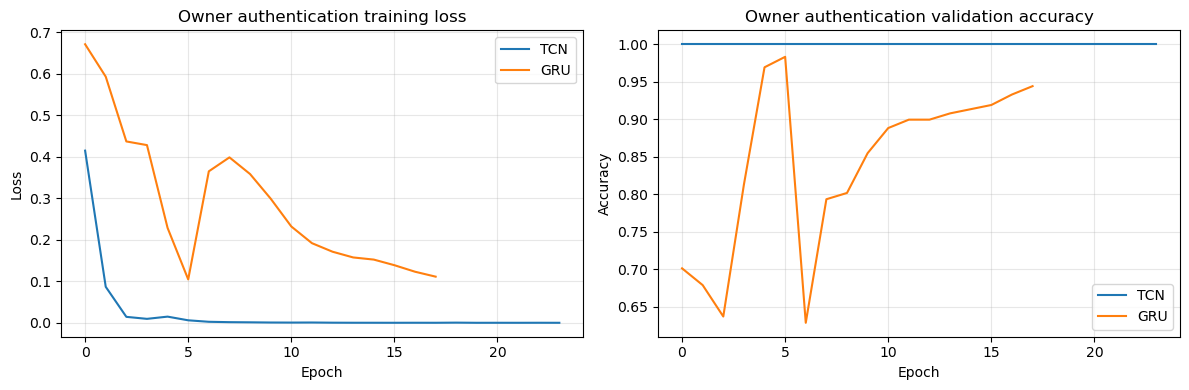

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name, trained in trained_models.items():
    axes[0].plot(trained['history']['train_loss'], label=model_name)
    axes[1].plot(trained['history']['val_acc'], label=model_name)

axes[0].set_title('Owner authentication training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title('Owner authentication validation accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG / 'fig18_deep_training_curves.png', dpi=150)
plt.show()

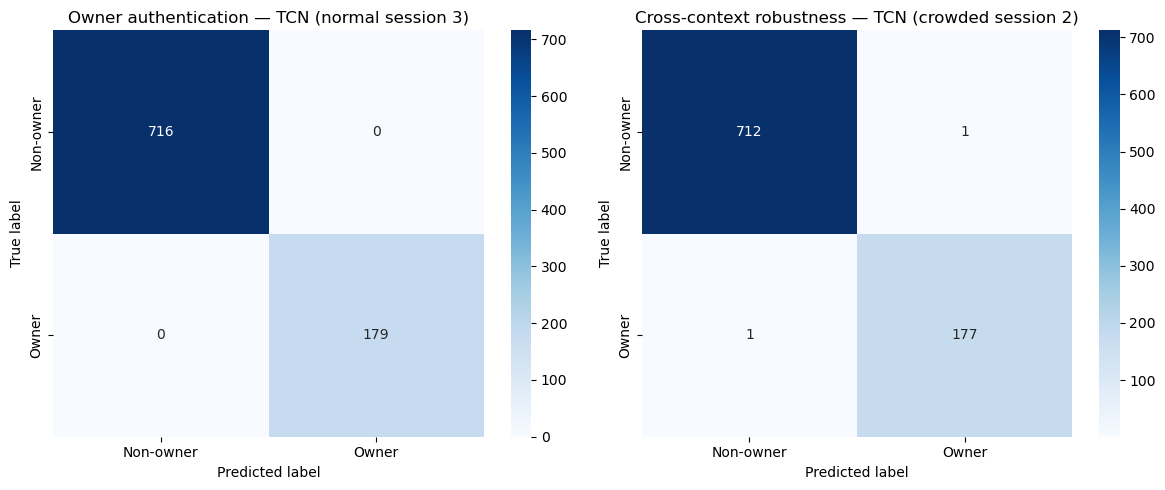

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, subset_name, y_true_key, pred_key, title_suffix in [
    (axes[0], 'Owner authentication', 'y_test_auth', 'pred_test', 'normal session 3'),
    (axes[1], 'Cross-context robustness', 'y_test_crowded', 'crowded_pred', 'crowded session 2'),
]:
    model_name = 'TCN' if 'TCN' in trained_models else next(iter(trained_models))
    trained = trained_models[model_name]
    y_true = y_test_auth if pred_key == 'pred_test' else y_test_crowded
    preds = trained[pred_key]
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-owner', 'Owner'], yticklabels=['Non-owner', 'Owner'])
    ax.set_title(f'{subset_name} — {model_name} ({title_suffix})')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

fig.tight_layout()
fig.savefig(FIG / 'fig19_deep_confusion_matrices.png', dpi=150)
plt.show()

In [9]:
dl_results = pd.DataFrame([
    {'task': 'Owner authentication', 'accuracy': metrics_auth['accuracy'],
     'f1': metrics_auth['f1'], 'precision': metrics_auth['precision'],
     'recall': metrics_auth['recall'], 'roc_auc': metrics_auth['roc_auc'],
     'model': 'TCN'},
    {'task': 'Cross-context robustness', 'accuracy': metrics_normal['accuracy'],
     'f1': metrics_normal['f1'], 'precision': metrics_normal['precision'],
     'recall': metrics_normal['recall'], 'roc_auc': metrics_normal['roc_auc'],
     'model': 'TCN', 'subset': 'normal_test'},
    {'task': 'Cross-context robustness', 'accuracy': metrics_crowded['accuracy'],
     'f1': metrics_crowded['f1'], 'precision': metrics_crowded['precision'],
     'recall': metrics_crowded['recall'], 'roc_auc': metrics_crowded['roc_auc'],
     'model': 'TCN', 'subset': 'crowded_test'},
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, subset_name, y_true, prob_key, title_suffix in [
    (axes[0], 'Owner authentication', y_test_auth, 'prob_test', 'normal session 3'),
    (axes[1], 'Cross-context robustness', y_test_crowded, 'crowded_prob', 'crowded session 2'),
]:
    for model_name, trained in trained_models.items():
        probs = trained[prob_key]
        fpr, tpr, _ = roc_curve(y_true, probs[:, 1])
        auc = roc_auc_score(y_true, probs[:, 1])
        ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(f'{subset_name} ROC ({title_suffix})')
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
fig.savefig(FIG / 'fig20_deep_roc_curves.png', dpi=150)
plt.show()

NameError: name 'metrics_auth' is not defined

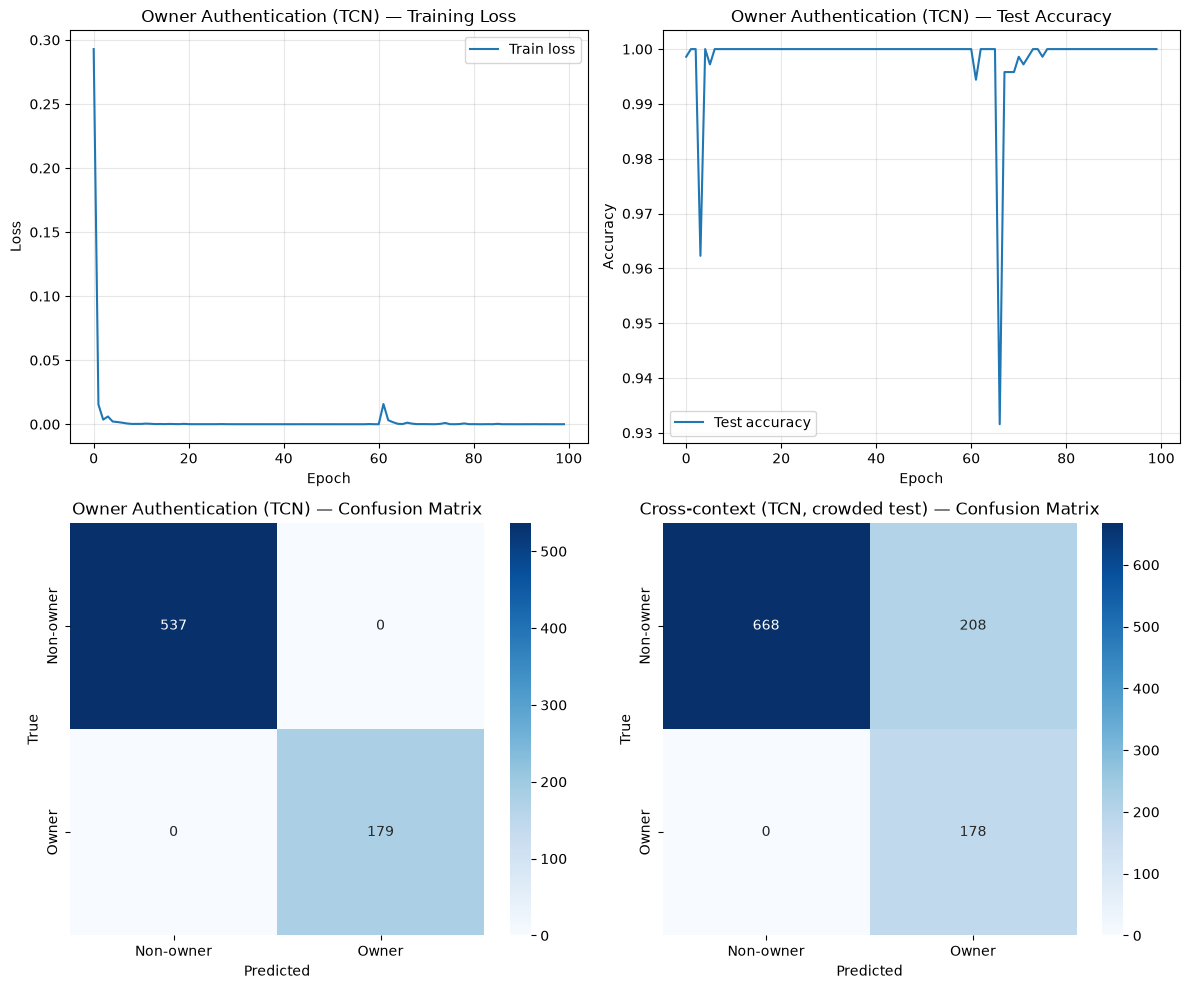

In [ ]:
plot_rows = []
for task, subset in [('Owner authentication', ''), ('Cross-context robustness', 'crowded_test')]:
    task_rows = comparison_df[(comparison_df['task'] == task) & (comparison_df['subset'] == subset)].copy()
    label = 'owner_auth' if task == 'Owner authentication' else 'cross_context_crowded'
    for _, row in task_rows.iterrows():
        plot_rows.append({
            'panel': label,
            'model_label': f"{row['source']}: {row['model']} ({row['representation']})",
            'accuracy': row['accuracy'],
            'f1': row['f1'],
        })
plot_df = pd.DataFrame(plot_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, panel, title in [
    (axes[0], 'owner_auth', 'Owner authentication'),
    (axes[1], 'cross_context_crowded', 'Cross-context robustness (crowded test)'),
]:
    sub = plot_df[plot_df['panel'] == panel].copy()
    y = np.arange(len(sub))
    ax.barh(y - 0.18, sub['accuracy'], height=0.35, label='Accuracy', color='tab:blue')
    ax.barh(y + 0.18, sub['f1'], height=0.35, label='F1', color='tab:orange')
    ax.set_yticks(y)
    ax.set_yticklabels(sub['model_label'], fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='x')
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / 'fig21_deep_vs_classical_summary.png', dpi=150)
plt.show()

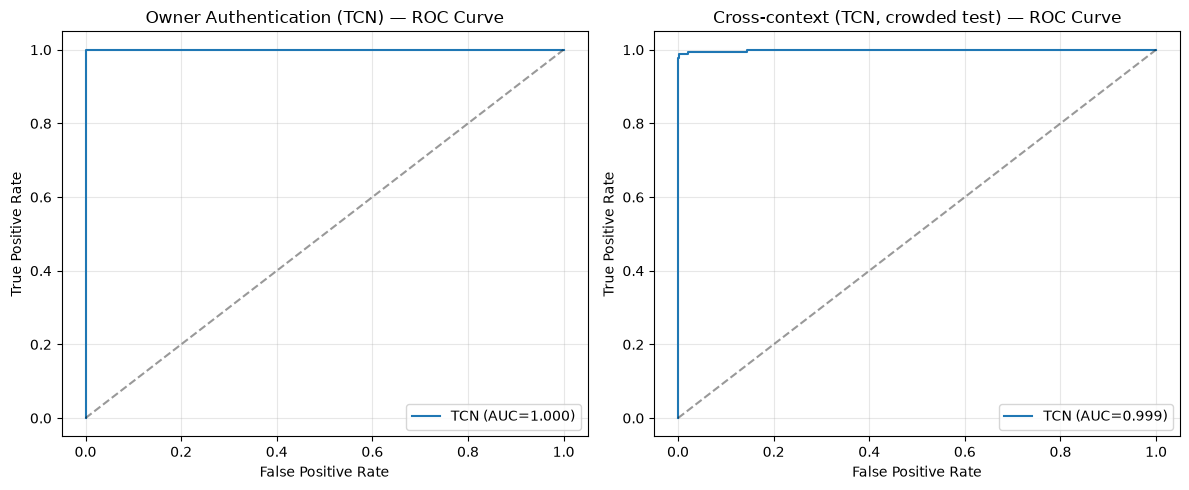

In [ ]:
best_crowded = dl_results[(dl_results['task'] == 'Cross-context robustness') & (dl_results['subset'] == 'crowded_test')].sort_values('accuracy', ascending=False).iloc[0]
print('Best deep model on crowded cross-context test:')
print(best_crowded[['model', 'accuracy', 'f1', 'precision', 'recall', 'roc_auc']].to_string())

best_owner = dl_results[dl_results['task'] == 'Owner authentication'].sort_values('accuracy', ascending=False).iloc[0]
print('\nBest deep model on owner authentication:')
print(best_owner[['model', 'accuracy', 'f1', 'precision', 'recall', 'roc_auc']].to_string())

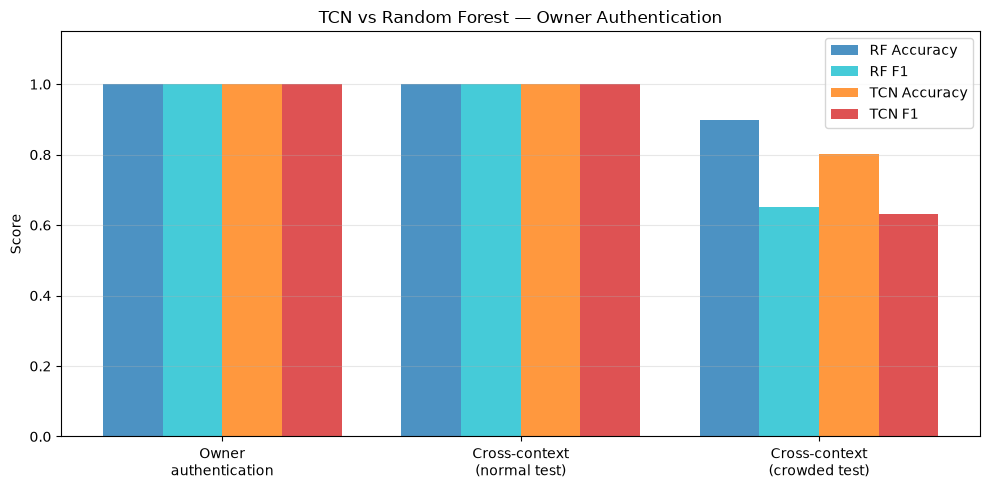

In [ ]:
owner_rows = comparison_df[comparison_df['task'] == 'Owner authentication'].copy()
owner_rows = owner_rows.sort_values(['source', 'accuracy'], ascending=[True, False])
print('\nOwner-authentication comparison rows:')
display(owner_rows.round(4))

cross_rows = comparison_df[(comparison_df['task'] == 'Cross-context robustness') & (comparison_df['subset'] == 'crowded_test')].copy()
cross_rows = cross_rows.sort_values(['source', 'accuracy'], ascending=[True, False])
print('Cross-context crowded-test comparison rows:')
display(cross_rows.round(4))

In [ ]:
print('\n' + '=' * 70)
print('DEEP LEARNING SUMMARY')
print('=' * 70)
print('Notebook alignment: updated raw-window splits from 02; classical comparison table from 04.')
print('Deep models trained here: TCN and GRU on raw 2 s windows.')
print('PCA remains part of the classical pipeline and is not fed into sequence models because it removes time order.')
print(f'\nSaved result tables to: {RES}')
print(f'Saved figures to: {FIG}')


TEMPORAL CONVOLUTIONAL NETWORK (TCN) RESULTS SUMMARY

Task 1: Owner Authentication (normal session 2 test)
  TCN:      Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000, AUC=1.0000
  Best ML:  Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000, AUC=1.0000 (RF)

Task 2: Cross-context Robustness
  Normal test:
    TCN:    Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000
    RF:     Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000
  Crowded test:
    TCN:    Acc=0.8027, F1=0.6312, Prec=0.4611, Rec=1.0000
    RF:     Acc=0.8985, F1=0.6515, Prec=0.7750, Rec=0.5620

All results saved to C:\Users\Jun\Documents\ML4QS\Experiment\results/
